In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/CTC44/2025_12_03/svg_maps/'

In [2]:
map_path = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49' # CTC 44 PFQNM. THIS ONE HAS GOOD CURVES, CAN DO FITS
# path_ting = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/tingFit_halfRet_LV_YS_ting_results.csv'
path_hertz = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/hertz_results_lv_version_hertz_results.csv'

# path_ting = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/tingFit_halfRet_LV_YS_ting_results.csv'

path_ting = '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/tingFit_felix_LS_ting_results.csv'

saveSVG = False
lastColFirst = True


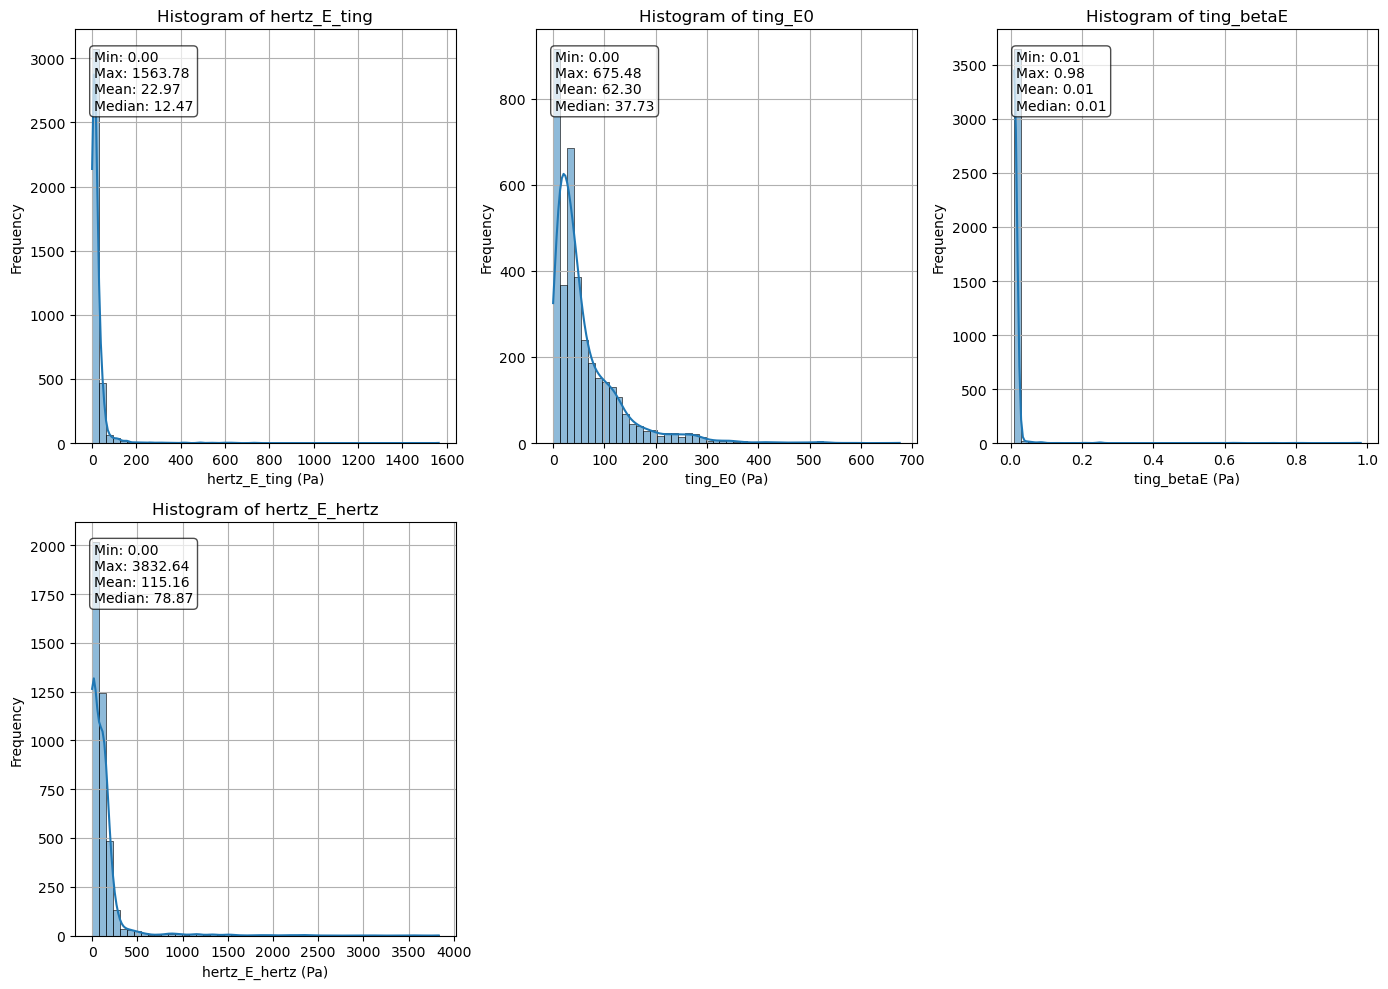

In [71]:
# open two dataframes and merge them in term of columns


df1 = pd.read_csv(path_ting)
# path_hertz = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45/results/hertz_v2_AfterLorenzoFix_hertz_results.csv'


df2 = pd.read_csv(path_hertz)

# Merge and match each row from both dataframes based on file_id. Assuming both dataframes have a 'file_id' column
df_merged_1 = pd.merge(df1, df2, on='file_path', suffixes=('_ting', '_hertz'))
# df_merged.head()
keys_to_plot = ['hertz_E_ting', 'ting_E0', 'ting_betaE','hertz_E_hertz']
maps.create_filtered_histogram(df_merged_1, keys_to_plot, filter_range=(0, 4000), bins=50)


In [5]:
df_merged_1.columns

Index(['file_path', 'file_id_ting', 'curve_idx_ting', 'kcanti_ting',
       'defl_sens_ting', 'hertz_ind_geometry_ting', 'hertz_tip_parameter_ting',
       'hertz_apply_BEC_ting', 'hertz_BEC_model_ting',
       'hertz_fit_hline_on_baseline_ting', 'hertz_delta0_ting', 'hertz_E_ting',
       'hertz_f0_ting', 'hertz_slope_ting', 'hertz_poisson_ratio_ting',
       'hertz_sample_height_ting', 'hertz_MAE_ting', 'hertz_MSE_ting',
       'hertz_RMSE_ting', 'hertz_Rsquared_ting', 'hertz_chisq_ting',
       'hertz_redchi_ting', 'ting_ind_geometry', 'ting_tip_parameter',
       'ting_modelFt', 'ting_apply_BEC', 'ting_BEC_model',
       'ting_fit_hline_on_baseline', 'ting_t0', 'ting_E0', 'ting_tc',
       'ting_betaE', 'ting_f0', 'ting_poisson_ratio', 'ting_vdrag',
       'ting_smooth_w', 'ting_idx_tm', 'ting_MAE', 'ting_MSE', 'ting_RMSE',
       'ting_Rsquared', 'ting_chisq', 'ting_redchi', 'ting_v0t_app_vel',
       'ting_v0r_ret_vel', 'file_id_hertz', 'curve_idx_hertz', 'kcanti_hertz',
       '

In [32]:
# show all columns in df_merged_1 that contain hertz_E
hertz_cols = [c for c in df_merged_1.columns if "hertz_E" in c]
hertz_cols

['hertz_E_ting', 'hertz_E_hertz']

In [6]:
# in df_merged_1, find all columns that contain hertz_E and show them
hertz_cols = [c for c in df_merged_1.columns if "hertz_E" in c]
hertz_cols

['hertz_E_ting', 'hertz_E_hertz']

### create map from fit parameters


In [7]:
# print (map_path)
new_path = os.path.join(map_path, 'results')

if os.path.exists(new_path):
    print (f"Directory {new_path} exists.")
    svg_dir = new_path

Directory /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results exists.


In [8]:
# path_ting = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.23.11.20/results/ting_v1_psnex_map___2025.03.12_18.23.11.20_ting_results.csv'
# map_path = '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.23.11.20/'
map_name = os.path.basename(os.path.normpath(map_path))



In [9]:
# open CSV files
df_ting = pd.read_csv(path_ting)

df_ting.head()

,file_path,file_id,curve_idx,kcanti,defl_sens,hertz_ind_geometry,hertz_tip_parameter,hertz_apply_BEC,hertz_BEC_model,hertz_fit_hline_on_baseline,...,ting_smooth_w,ting_idx_tm,ting_MAE,ting_MSE,ting_RMSE,ting_Rsquared,ting_chisq,ting_redchi,ting_v0t_app_vel,ting_v0r_ret_vel
0,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.03.97.tdms,0,0.0734,17.1,pyramid,35.0,False,NaN,False,...,5.0,292.0,8.123680e-18,1.977696e-21,4.447129e-11,0.950732,-1.305199e-09,-3.262998e-10,0.00002,0.001
1,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.12.81.tdms,0,0.0734,17.1,pyramid,35.0,False,NaN,False,...,5.0,292.0,-1.328573e-17,4.322594e-21,6.574644e-11,0.889623,7.023412e-09,1.755853e-09,0.00002,0.001
2,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.05.85.tdms,0,0.0734,17.1,pyramid,35.0,False,NaN,False,...,5.0,291.0,5.888265e-17,8.376845e-21,9.152511e-11,0.776329,1.756094e-08,4.390236e-09,0.00002,0.001
3,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.16.41.tdms,0,0.0734,17.1,pyramid,35.0,False,NaN,False,...,5.0,292.0,4.029235e-17,3.639027e-21,6.032435e-11,0.911276,3.035496e-09,7.588741e-10,0.00002,0.001
4,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.14.56.tdms,0,0.0734,17.1,pyramid,35.0,False,NaN,False,...,5.0,291.0,3.120496e-18,2.398033e-21,4.896971e-11,0.928319,3.812642e-09,9.531604e-10,0.00002,0.001


In [10]:
print (map_path)

/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49


In [11]:
df_dict_tdms, map_x_pix, map_y_pix, params = maps.load_map_file_square_tdms(map_path)
df_dict_tdms_1 = maps.load_map_psnex(map_path)
print (df_dict_tdms.columns)
df_dict_tdms.head()


# of files analyzed: 4096, closest shape: 64 x 64
 map metadata: map_x_step: 0.06233, map_y_step: 0.08173, map_x_init: 0.0, map_y_init: 0.0
 x_sens (um/V): 11.456, y_sens (um/V): 8.739, z_sens (um/V): 6.0, z_setpoint_trig (V): 7.061066
Index(['filepath', 'file_id', 'z_height_v', 'curve_index', 'x_index',
       'y_index', 'z_height_um', 'x_pos_um', 'y_pos_um', 'z_height_um_zero'],
      dtype='object')


,filepath,file_id,z_height_v,curve_index,x_index,y_index,z_height_um,x_pos_um,y_pos_um,z_height_um_zero
0,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.03.97.tdms,8.600098,1,0,0,51.600588,0.0000,0.0,1.518306
1,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.05.85.tdms,8.706451,2,1,0,52.238706,1.1456,0.0,0.880188
2,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.07.57.tdms,8.742035,3,2,0,52.452210,2.2912,0.0,0.666684
3,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.09.33.tdms,8.752716,4,3,0,52.516296,3.4368,0.0,0.602598
4,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.11.09.tdms,8.768158,5,4,0,52.608948,4.5824,0.0,0.509946


In [51]:
bool_error, mismatch_indices = maps.check_map_indice_integrity(df_dict_tdms, map_x_pix, map_y_pix)
if bool_error:
    x_pos_1d, y_pos_1d, curve_index = maps.generate_xy_map_positions(map_x_pix=map_x_pix, map_y_pix=map_y_pix)
    x_indices = x_pos_1d
    y_indices = y_pos_1d
    print ('Map indices were regenerated due to integrity error')   

    # sort mismatch indices based on time from file ID
    df_time = maps.compute_time_difference(map_path)

    # Remove duplicates from df_time based on filepath (keep first occurrence)
    df_time = df_time.drop_duplicates(subset='filepath', keep='first')

    

    # Merge based on filepath - this should now be 1:1
    df_merged_tdms = pd.merge(df_dict_tdms, df_time, on='filepath', how='left')

    # create copy of df_merged_tdms to avoid SettingWithCopyWarning
    df_merged_tdms_copy = df_merged_tdms.copy()

    # # merge def_ting to df_merged_tdms based on filepath
    df_merged_tdms_copy = pd.merge(df_merged_tdms_copy, df1, on='file_id', how='left')

    # # merge def_hertz to df_merged_tdms based on filepath
    df_merged_tdms_copy = pd.merge(df_merged_tdms_copy, df2, on='file_path', how='left')    

    # # insert x_indices and y_indices and curve index into df_merged_tdms
    df_merged_tdms_copy['x_index'] = x_indices
    df_merged_tdms_copy['y_index'] = y_indices
    df_merged_tdms_copy['curve_index'] = curve_index

    # Check if we have the expected number of rows
    print(f"df_map rows: {len(df_dict_tdms)}")
    print(f"df_time rows: {len(df_time)}")
    print(f"df_merged_tdms rows: {len(df_merged_tdms)}")




4096 Mismatched indices: [0 1 2 3 4 5 6 7 8 9]
Shape of x_pos_1d: (4096,)
Shape of y_pos_1d: (4096,)
Map indices were regenerated due to integrity error
Files processed: 4096, matches found: 4096

Time difference between first and last file HH:MM:SS:MS: 00:57:19:95
df_map rows: 4096
df_time rows: 4096
df_merged_tdms rows: 4096


In [52]:
df_merged_tdms_copy.head()

,filepath,file_id_x,z_height_v,curve_index,x_index,y_index,z_height_um,x_pos_um,y_pos_um,z_height_um_zero,...,hertz_f0_y,hertz_slope_y,hertz_poisson_ratio_y,hertz_sample_height_y,hertz_MAE_y,hertz_MSE_y,hertz_RMSE_y,hertz_Rsquared_y,hertz_chisq_y,hertz_redchi_y
0,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.03.97.tdms,8.600098,0,0,0,51.600588,0.0000,0.0,1.518306,...,1.714997e-11,NaN,0.5,NaN,1.766804e-19,6.262824e-21,7.913801e-11,0.761905,-0.000003,-8.432059e-07
1,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.05.85.tdms,8.706451,1,1,0,52.238706,1.1456,0.0,0.880188,...,2.975864e-11,NaN,0.5,NaN,1.940895e-22,2.501782e-21,5.001782e-11,0.857839,0.000002,7.370847e-07
2,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.07.57.tdms,8.742035,2,2,0,52.452210,2.2912,0.0,0.666684,...,1.347727e-11,NaN,0.5,NaN,6.831009e-22,3.321112e-21,5.762909e-11,0.845572,-0.000002,-6.209119e-07
3,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.09.33.tdms,8.752716,3,3,0,52.516296,3.4368,0.0,0.602598,...,2.777918e-11,NaN,0.5,NaN,2.361096e-22,4.281571e-21,6.543371e-11,0.782198,0.000003,8.824525e-07
4,/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_2...,fcurve___2026.04.23_15.40.11.09.tdms,8.768158,4,4,0,52.608948,4.5824,0.0,0.509946,...,5.305979e-11,NaN,0.5,NaN,4.623819e-22,1.202788e-20,1.096717e-10,0.531861,-0.000011,-3.555892e-06


In [53]:
df_merged_tdms_copy.columns

Index(['filepath', 'file_id_x', 'z_height_v', 'curve_index', 'x_index',
       'y_index', 'z_height_um', 'x_pos_um', 'y_pos_um', 'z_height_um_zero',
       'datetime', 'file_path', 'curve_idx_x', 'kcanti_x', 'defl_sens_x',
       'hertz_ind_geometry_x', 'hertz_tip_parameter_x', 'hertz_apply_BEC_x',
       'hertz_BEC_model_x', 'hertz_fit_hline_on_baseline_x', 'hertz_delta0_x',
       'hertz_E_x', 'hertz_f0_x', 'hertz_slope_x', 'hertz_poisson_ratio_x',
       'hertz_sample_height_x', 'hertz_MAE_x', 'hertz_MSE_x', 'hertz_RMSE_x',
       'hertz_Rsquared_x', 'hertz_chisq_x', 'hertz_redchi_x',
       'ting_ind_geometry', 'ting_tip_parameter', 'ting_modelFt',
       'ting_apply_BEC', 'ting_BEC_model', 'ting_fit_hline_on_baseline',
       'ting_t0', 'ting_E0', 'ting_tc', 'ting_betaE', 'ting_f0',
       'ting_poisson_ratio', 'ting_vdrag', 'ting_smooth_w', 'ting_idx_tm',
       'ting_MAE', 'ting_MSE', 'ting_RMSE', 'ting_Rsquared', 'ting_chisq',
       'ting_redchi', 'ting_v0t_app_vel', 'ting_v0r

In [54]:
# show only E-related columns for Hertz and Ting
e_cols = [c for c in df_merged_tdms_copy.columns if ("_E" in c and ("hertz" in c or "ting" in c or "_E0" in c))]
e_cols

['hertz_E_x', 'ting_E0', 'hertz_E_y']

Using provided DataFrame for heatmap
Map dimensions: 64 x 64
zmax: 25, zmin: 0.0
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/z_height_um_zero_psnex_map___2026.04.23_15.39.46.49.svg


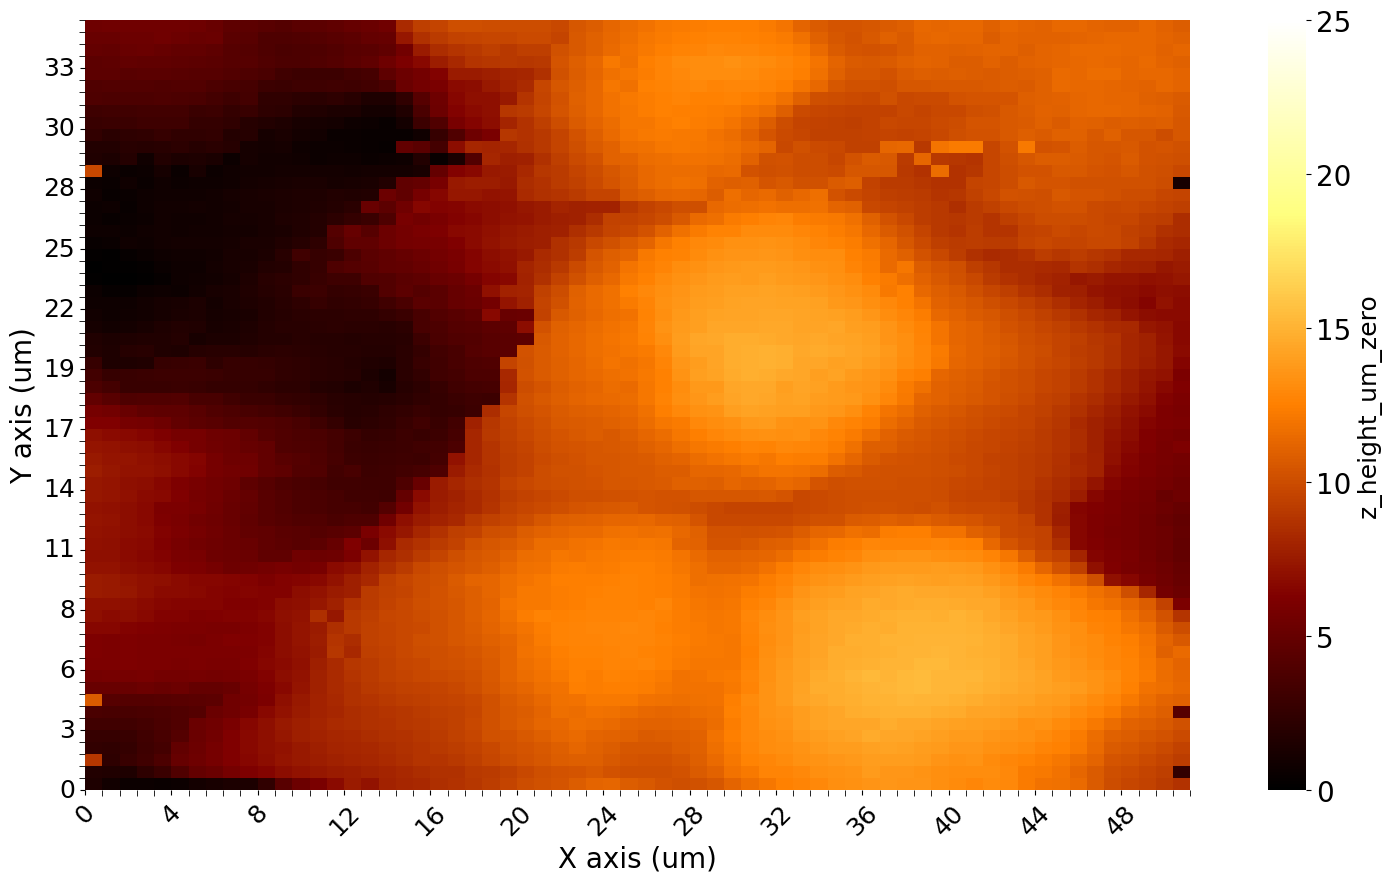

In [55]:
key1 = "z_height_um_zero"

_ = maps.create_heatmap(df_merged_tdms_copy,value_key = key1, annot=False,
                        save_svg=False , svg_path= os.path.join(svg_dir, f'{key1}_{map_name}.svg'),
                        cmap = 'afmhot_r', nan = True , lastColFirst=False, scale_axis=True, zmax =25, scaleBar = False
                        )

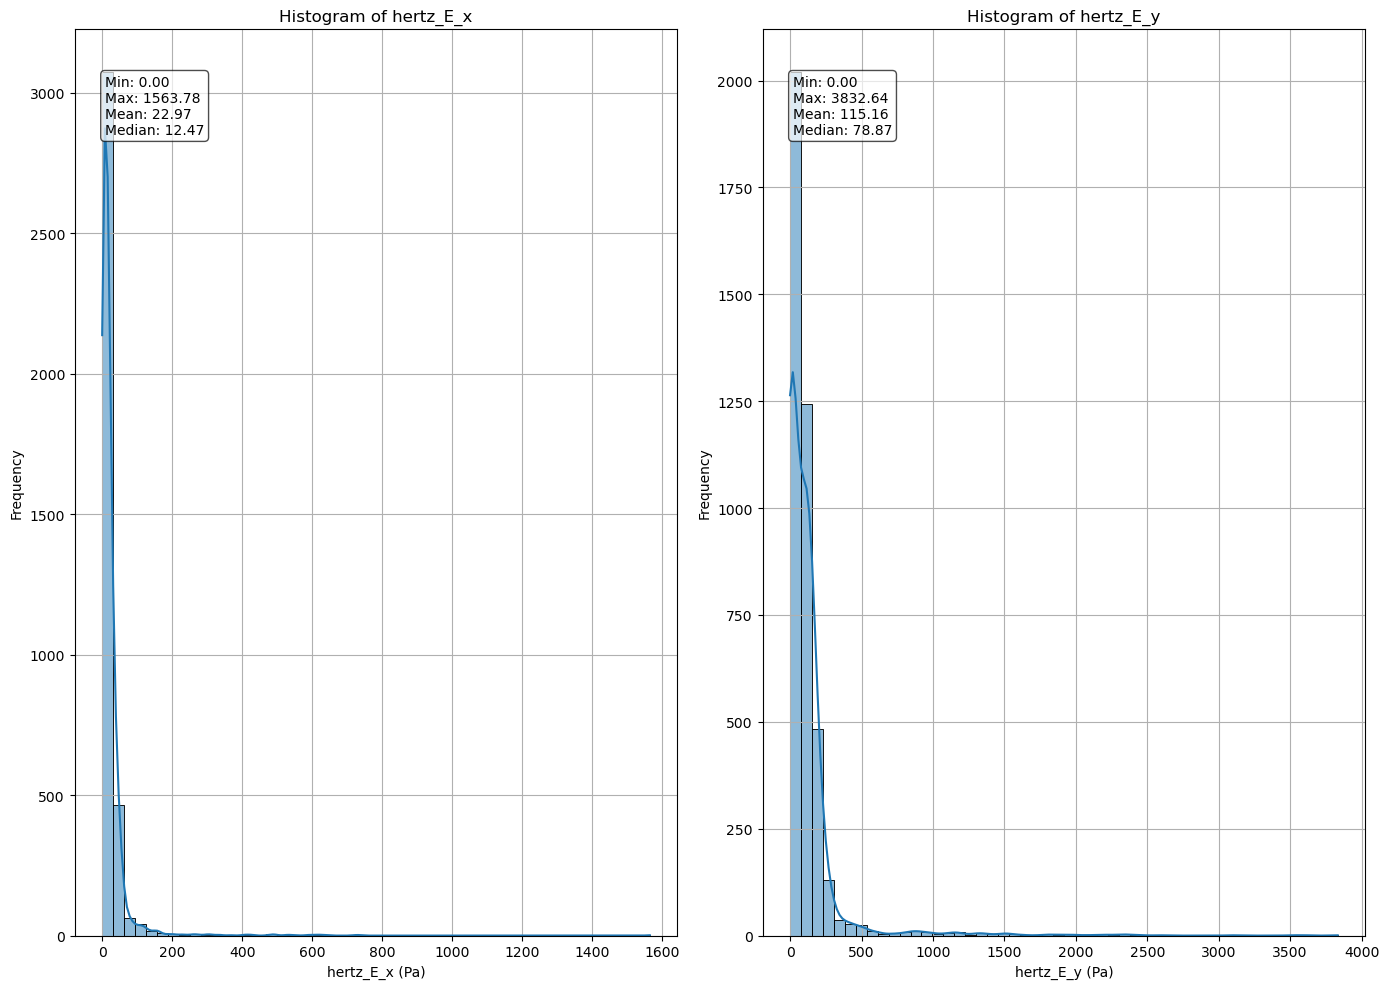

In [56]:
keys_to_plot = ['hertz_E_x', 'hertz_E_y']
maps.create_filtered_histogram(df_merged_tdms_copy, keys_to_plot, filter_range=(0, 4000), bins=50)


Using provided DataFrame for heatmap
Map dimensions: 64 x 64
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/hertz_E_x_psnex_map___2026.04.23_15.39.46.49.svg


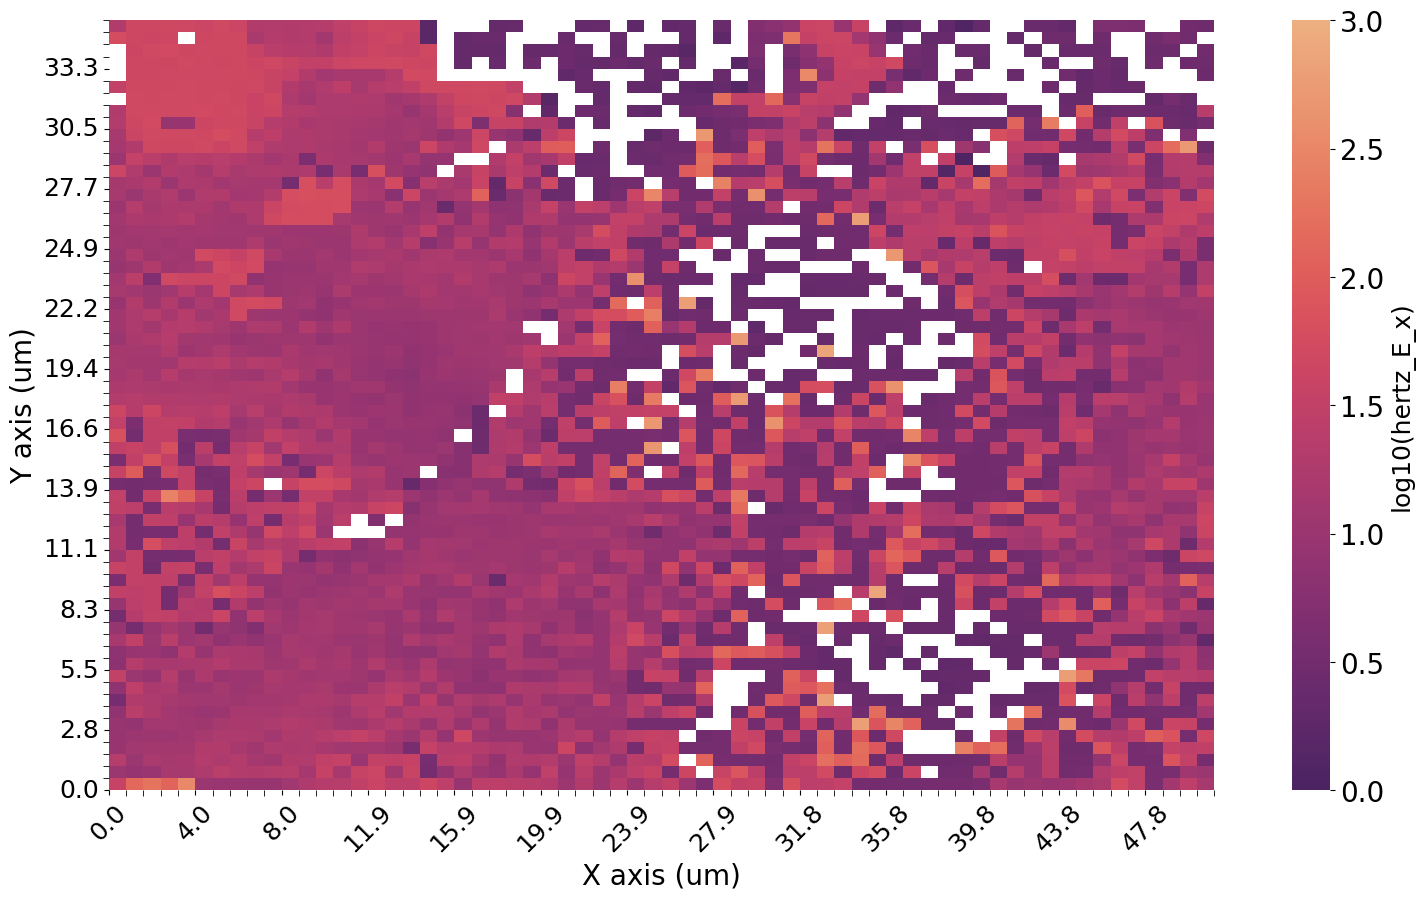

In [57]:
key1 = "hertz_E_x"

_ = maps.create_log_heatmap(df_merged_tdms_copy,value_key = key1, annot=False,
                        save_svg=True , svg_path= os.path.join(svg_dir, f'{key1}_{map_name}.svg'),
                        cmap = 'flare', nan = True , lastColFirst=False, scale_axis=True, scaleBar = False, zmax =1000, zmin = 1
                        )

Using provided DataFrame for heatmap
Map dimensions: 64 x 64
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/hertz_E_y_psnex_map___2026.04.23_15.39.46.49.svg


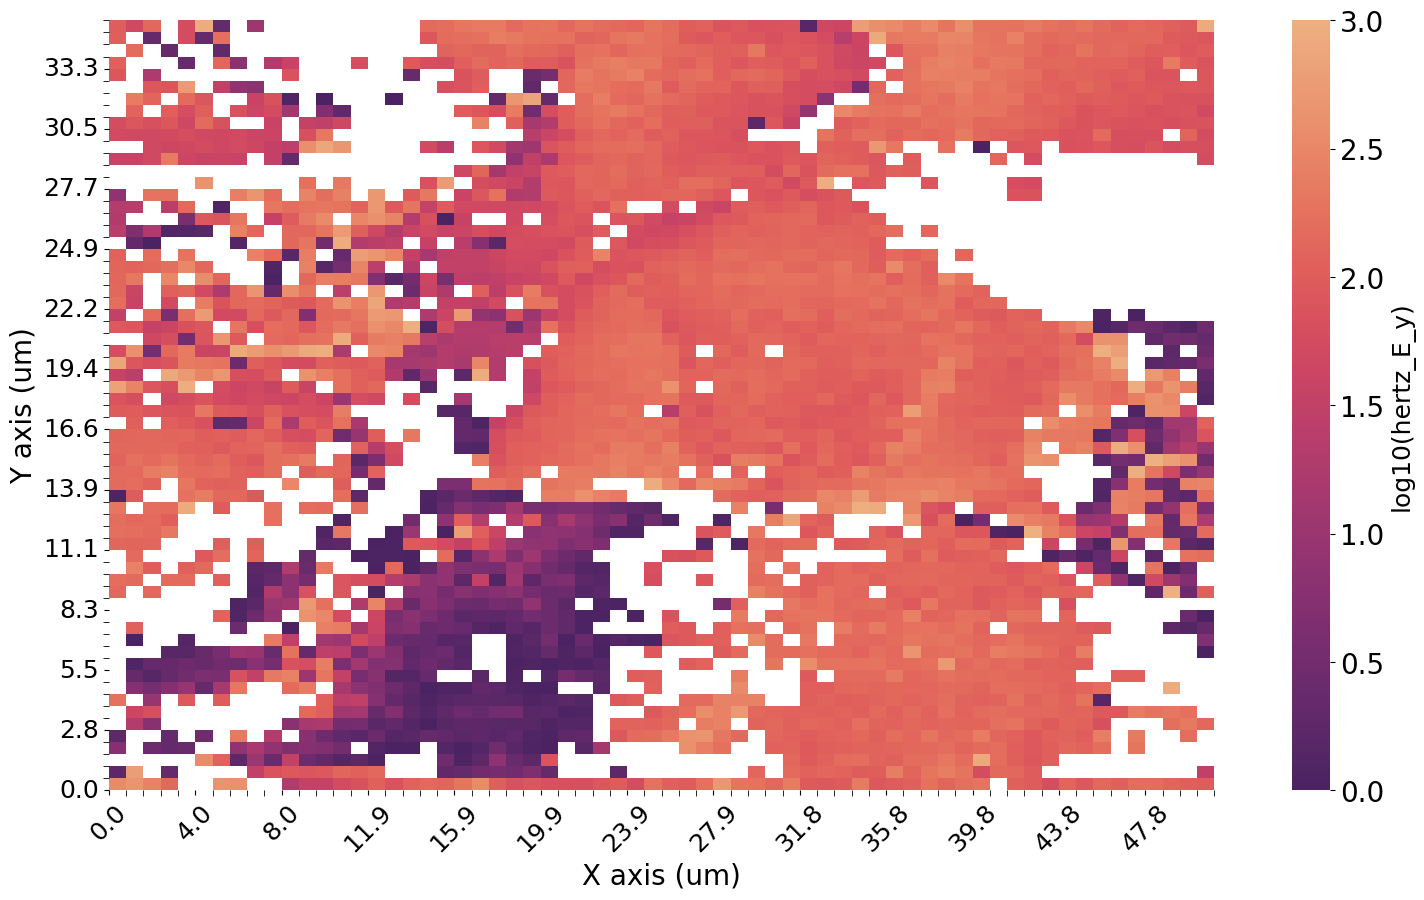

In [58]:
key = "hertz_E_y"


_ = maps.create_log_heatmap(df_merged_tdms_copy,value_key = key, annot=False,
                        save_svg=True , svg_path= os.path.join(svg_dir, f'{key}_{map_name}.svg'),
                        cmap = 'flare', nan = True , lastColFirst=False, scale_axis=True, scaleBar = False, zmax =1000, zmin = 1
                        )

In [59]:
# show all columns in df_merged_1 that contain hertz_E
hertz_cols = [c for c in df_merged_tdms_copy.columns if "hertz" in c]
hertz_cols

['hertz_ind_geometry_x',
 'hertz_tip_parameter_x',
 'hertz_apply_BEC_x',
 'hertz_BEC_model_x',
 'hertz_fit_hline_on_baseline_x',
 'hertz_delta0_x',
 'hertz_E_x',
 'hertz_f0_x',
 'hertz_slope_x',
 'hertz_poisson_ratio_x',
 'hertz_sample_height_x',
 'hertz_MAE_x',
 'hertz_MSE_x',
 'hertz_RMSE_x',
 'hertz_Rsquared_x',
 'hertz_chisq_x',
 'hertz_redchi_x',
 'hertz_ind_geometry_y',
 'hertz_tip_parameter_y',
 'hertz_apply_BEC_y',
 'hertz_BEC_model_y',
 'hertz_fit_hline_on_baseline_y',
 'hertz_delta0_y',
 'hertz_E_y',
 'hertz_f0_y',
 'hertz_slope_y',
 'hertz_poisson_ratio_y',
 'hertz_sample_height_y',
 'hertz_MAE_y',
 'hertz_MSE_y',
 'hertz_RMSE_y',
 'hertz_Rsquared_y',
 'hertz_chisq_y',
 'hertz_redchi_y']

Using provided DataFrame for heatmap
Map dimensions: 64 x 64
zmax: 1000, zmin: 6.985018230487583e-09
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/ting_E0_psnex_map___2026.04.23_15.39.46.49.svg


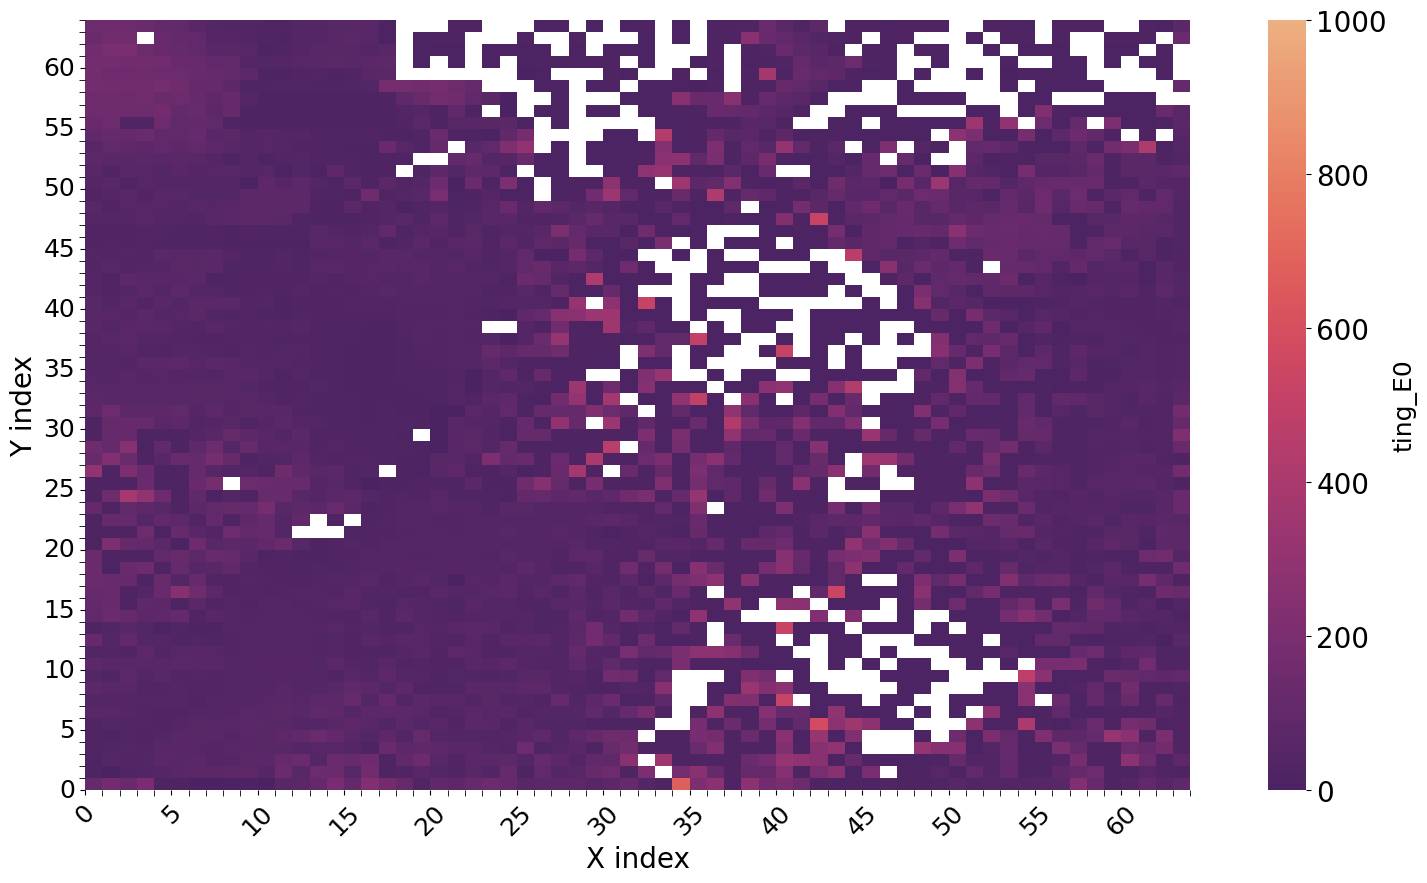

In [60]:
key2 = "ting_E0"
_ = maps.create_heatmap(df_merged_tdms_copy, value_key=key2, annot=False,
                        save_svg=False, svg_path=os.path.join(svg_dir, f'{key2}_{map_name}.svg'),
                        cmap="flare", nan= True, lastColFirst=lastColFirst, zmax = 1000)

NOTE!

To reverse the colormap so that dark colors represent lower values (zero) and light colors represent higher values, you need to append _r to the colormap name:

Using provided DataFrame for heatmap
Map dimensions: 64 x 64
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/log10_ting_E0_psnex_map___2026.04.23_15.39.46.49.svg


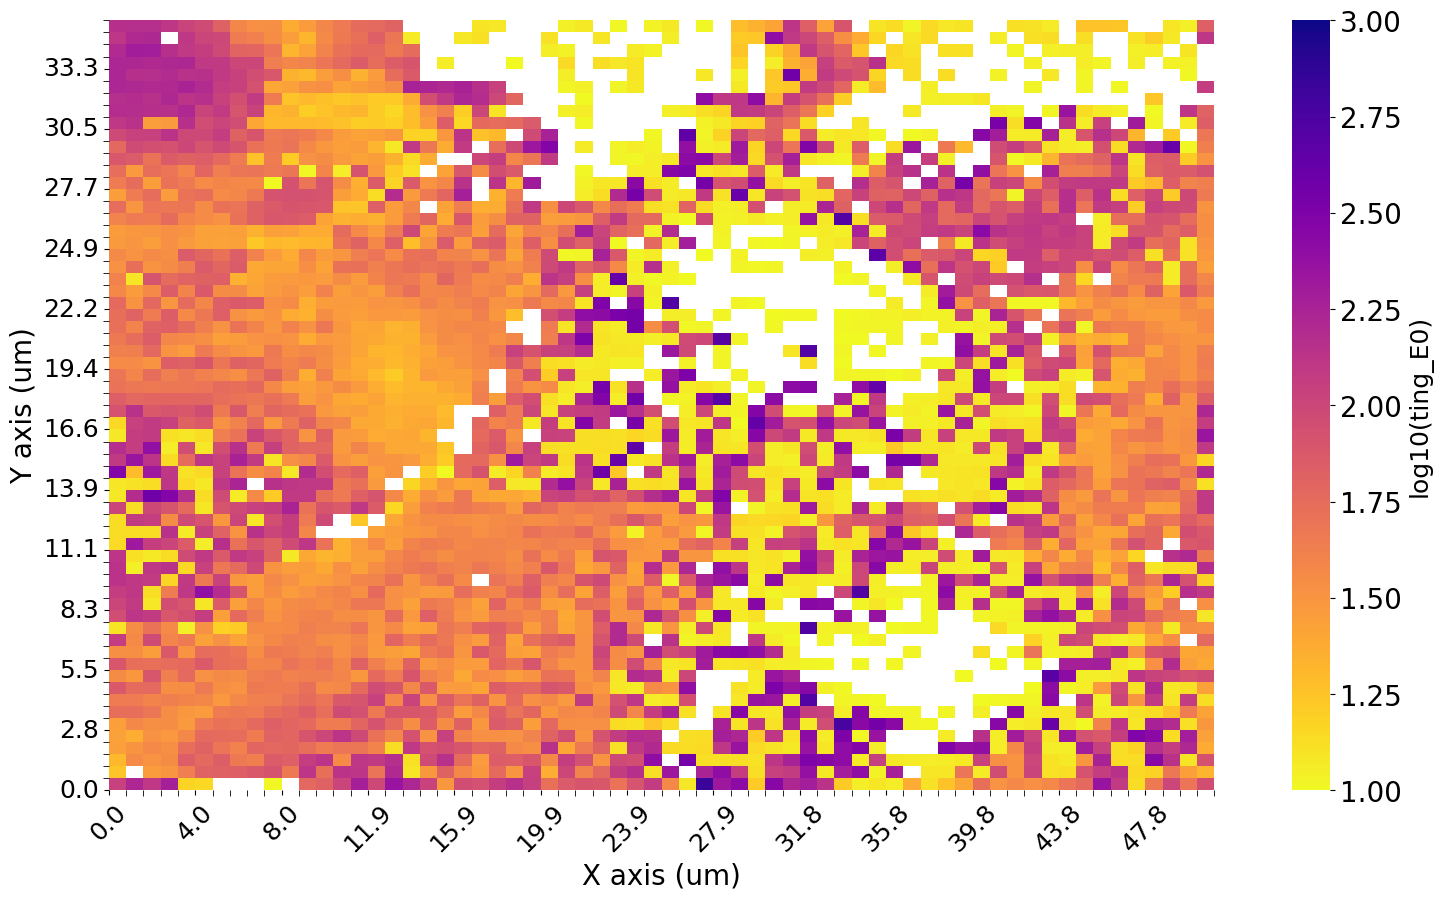

In [61]:
_ = maps.create_log_heatmap(df_merged_tdms_copy,value_key = key2, annot=False,
                        save_svg=saveSVG, svg_path=os.path.join(svg_dir, f'log10_{key2}_{map_name}.svg'),
                        cmap = 'plasma', nan=True, lastColFirst=lastColFirst, zmax = 1000, zmin =10, scale_axis=True
                        )
# print (saveSVG)

Using provided DataFrame for heatmap
Map dimensions: 64 x 64
zmax: 0.02, zmin: 0.01
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/ting_betaE_psnex_map___2026.04.23_15.39.46.49.svg


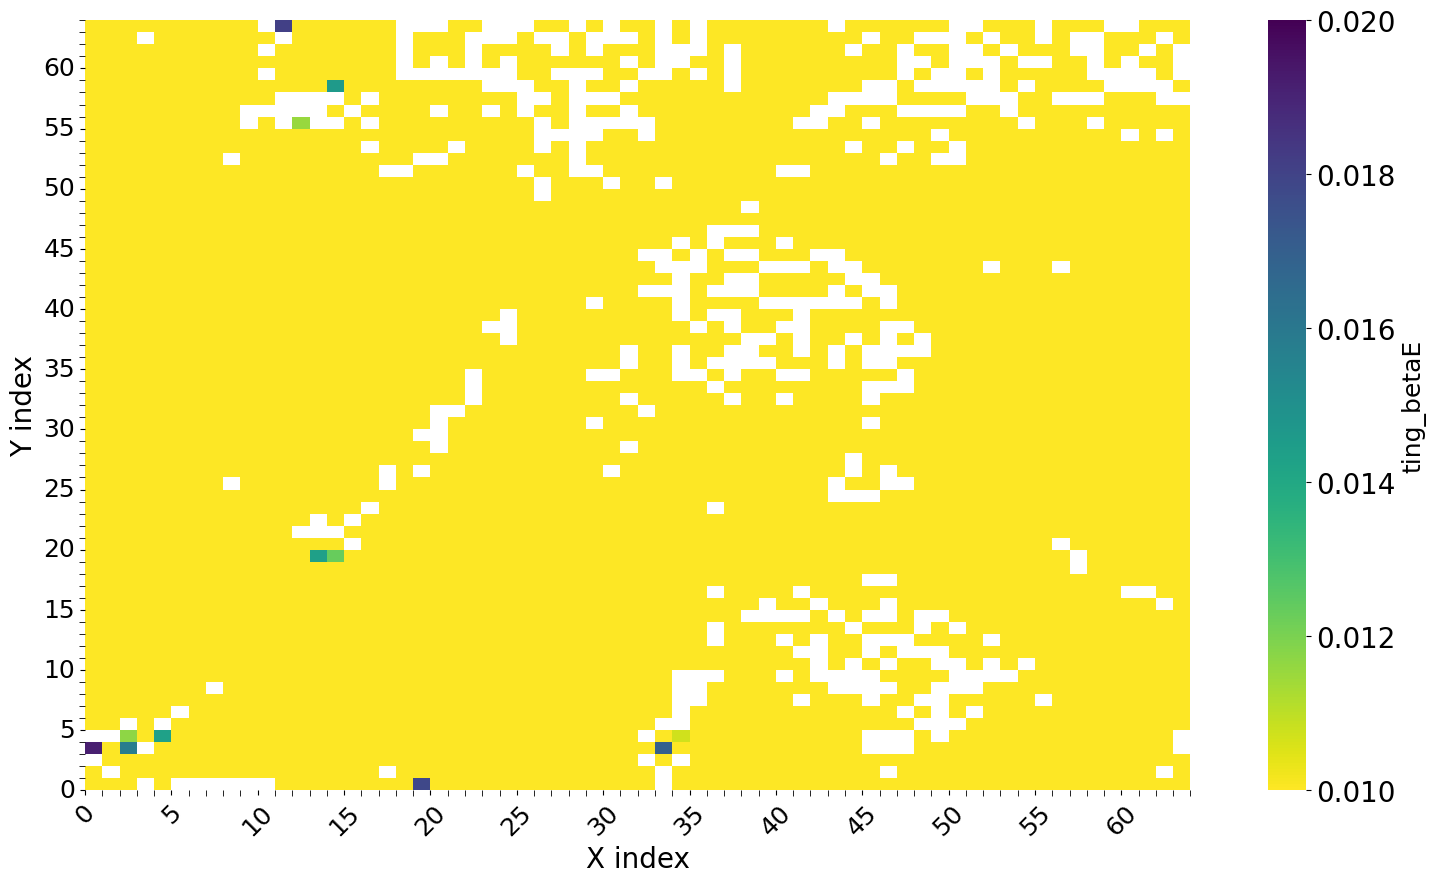

In [62]:
key3 = "ting_betaE"
_ = maps.create_heatmap(df_merged_tdms_copy,value_key = key3, annot=False,
                        save_svg=saveSVG, svg_path=os.path.join(svg_dir, f'{key3}_{map_name}.svg'),
                        cmap = 'viridis', nan=True, lastColFirst=lastColFirst, zmax = 0.02
                        )



Using provided DataFrame for heatmap
Map dimensions: 64 x 64
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/log10_ting_E0_psnex_map___2026.04.23_15.39.46.49.svg


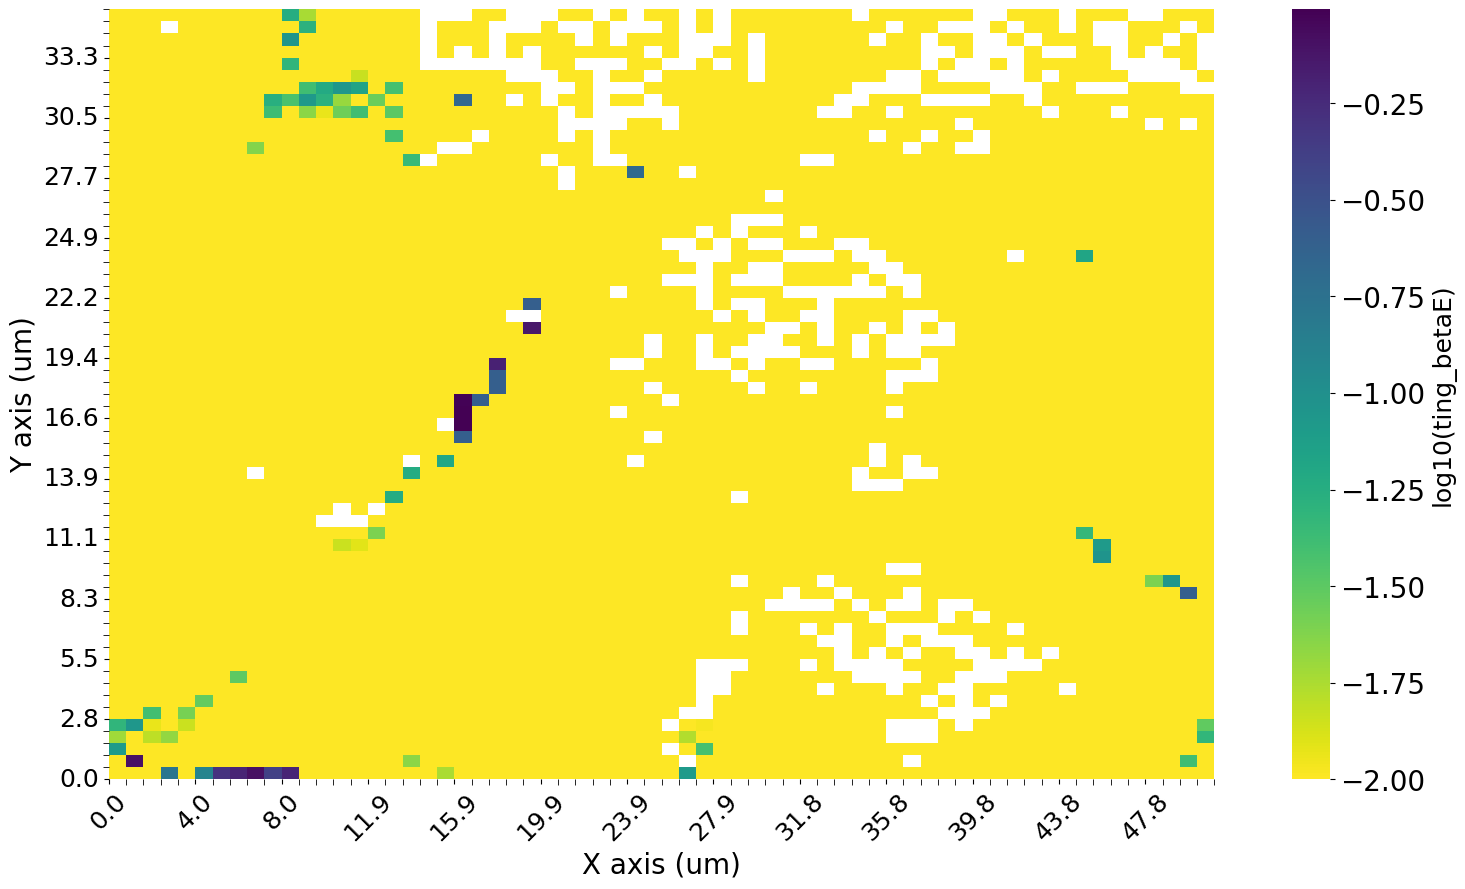

In [63]:
_ = maps.create_log_heatmap(df_merged_tdms_copy,value_key = key3, annot=False,
                        save_svg=saveSVG, svg_path=os.path.join(svg_dir, f'log10_{key2}_{map_name}.svg'),
                        cmap = 'viridis', nan=True, lastColFirst=lastColFirst, scale_axis=True
                        )

In [64]:
df_merged_tdms_copy.columns

Index(['filepath', 'file_id_x', 'z_height_v', 'curve_index', 'x_index',
       'y_index', 'z_height_um', 'x_pos_um', 'y_pos_um', 'z_height_um_zero',
       'datetime', 'file_path', 'curve_idx_x', 'kcanti_x', 'defl_sens_x',
       'hertz_ind_geometry_x', 'hertz_tip_parameter_x', 'hertz_apply_BEC_x',
       'hertz_BEC_model_x', 'hertz_fit_hline_on_baseline_x', 'hertz_delta0_x',
       'hertz_E_x', 'hertz_f0_x', 'hertz_slope_x', 'hertz_poisson_ratio_x',
       'hertz_sample_height_x', 'hertz_MAE_x', 'hertz_MSE_x', 'hertz_RMSE_x',
       'hertz_Rsquared_x', 'hertz_chisq_x', 'hertz_redchi_x',
       'ting_ind_geometry', 'ting_tip_parameter', 'ting_modelFt',
       'ting_apply_BEC', 'ting_BEC_model', 'ting_fit_hline_on_baseline',
       'ting_t0', 'ting_E0', 'ting_tc', 'ting_betaE', 'ting_f0',
       'ting_poisson_ratio', 'ting_vdrag', 'ting_smooth_w', 'ting_idx_tm',
       'ting_MAE', 'ting_MSE', 'ting_RMSE', 'ting_Rsquared', 'ting_chisq',
       'ting_redchi', 'ting_v0t_app_vel', 'ting_v0r

In [65]:
#filter an dshow column values that contain hertz in df_merged_tdms_copy 
hertz_cols = [c for c in df_merged_tdms_copy.columns if "hertz_E" in c]
hertz_cols

['hertz_E_x', 'hertz_E_y']

Using provided DataFrame for heatmap
Map dimensions: 64 x 64
zmax: 53.118894000000004, zmin: 37.768434
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/ting_betaE_psnex_map___2026.04.23_15.39.46.49.svg


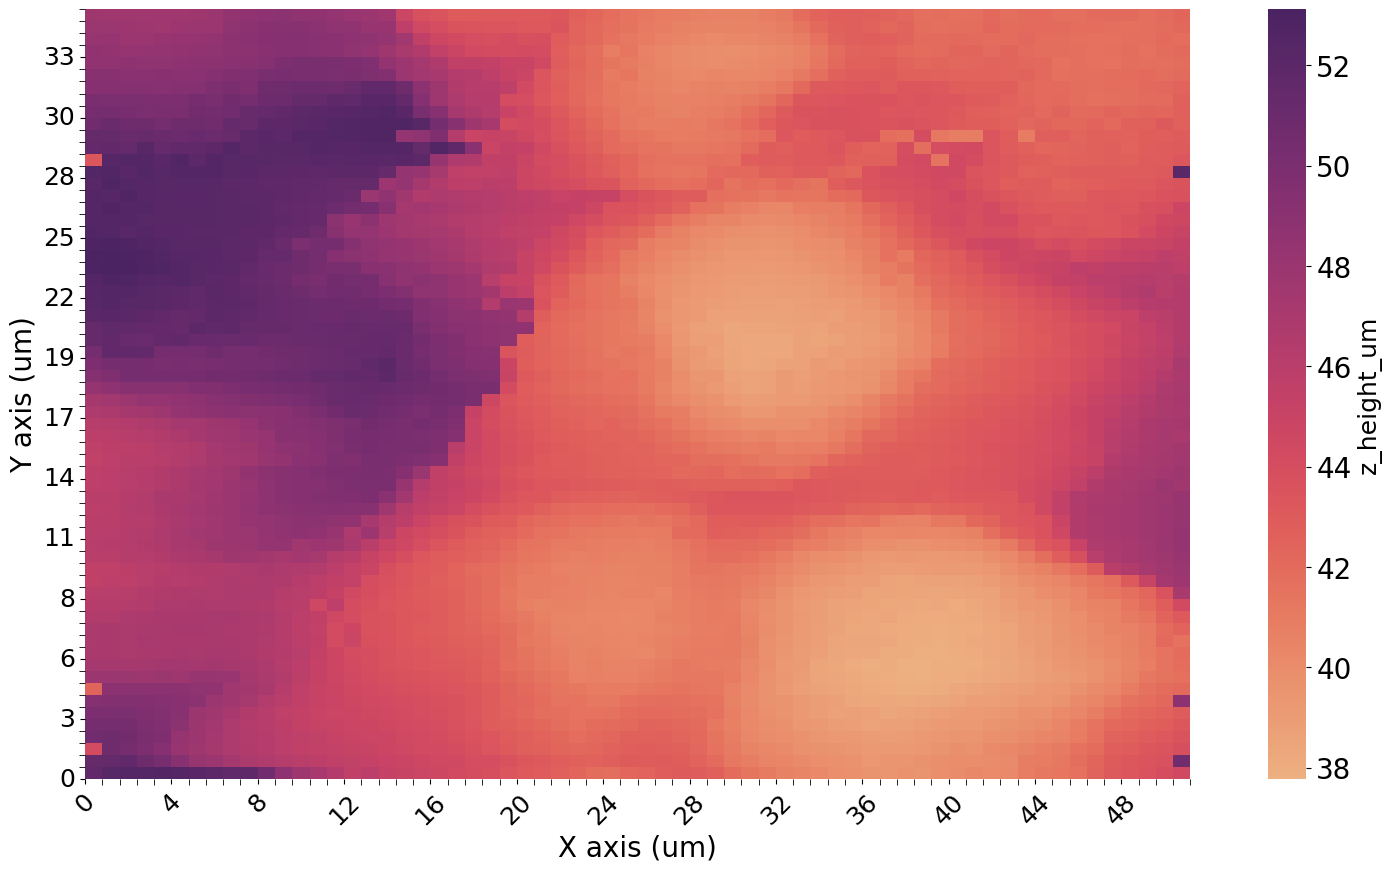

In [66]:
key_hertz = 'hertz_E'


_ = maps.create_heatmap(df_merged_tdms_copy,value_key = key_hertz, annot=False,
                        save_svg=False, svg_path=os.path.join(svg_dir, f'{key3}_{map_name}.svg'),
                        cmap = 'flare_r', nan=True, lastColFirst=False, scale_axis=True
                        )




Using provided DataFrame for heatmap
Map dimensions: 64 x 64
zmax: 675.4779467665496, zmin: 6.985018230487583e-09
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/ting_betaE_psnex_map___2026.04.23_15.39.46.49.svg


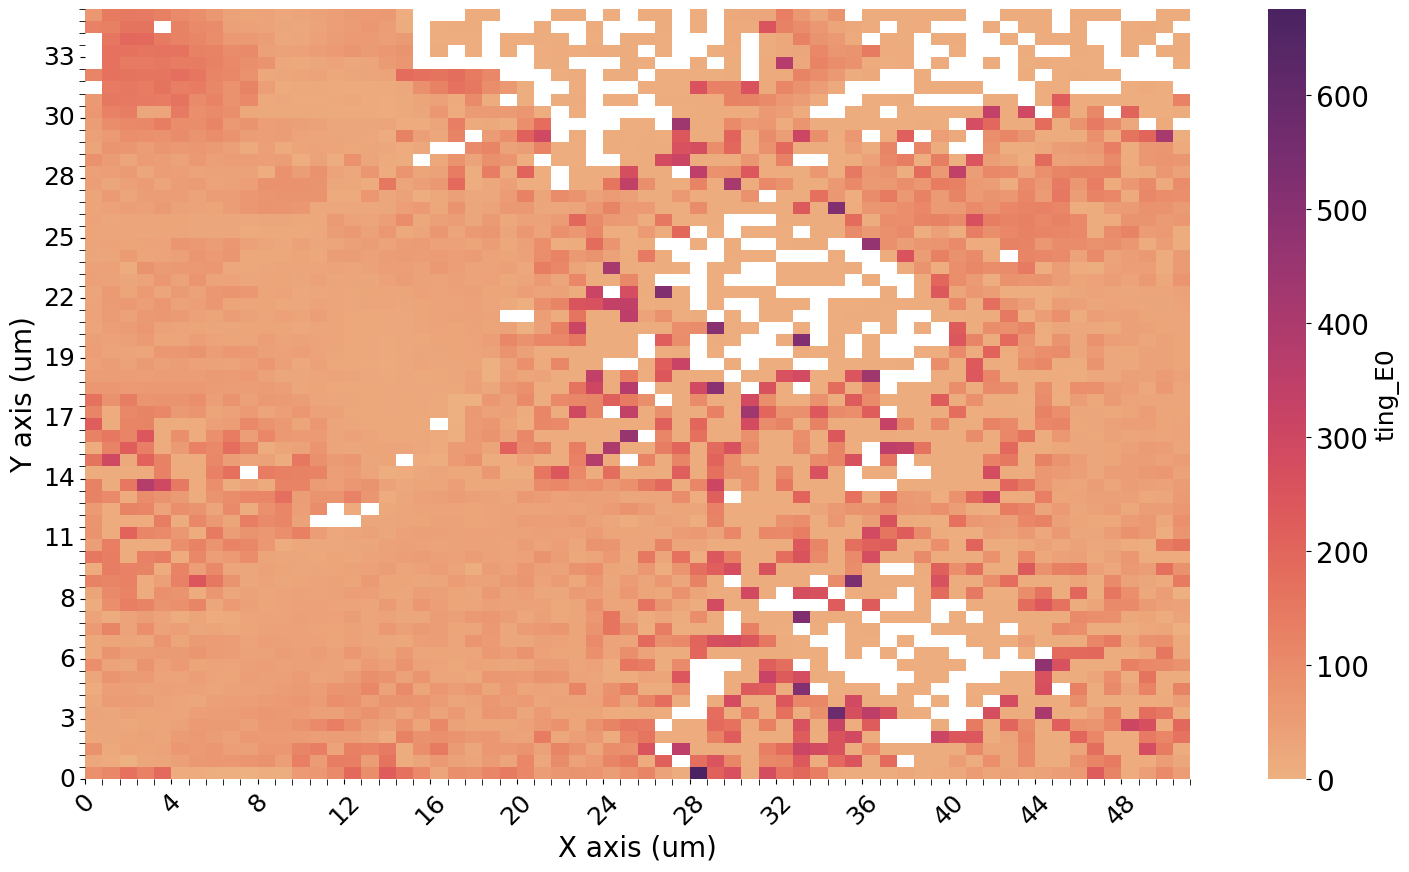

In [67]:
key_hertz = 'ting_E0'


_ = maps.create_heatmap(df_merged_tdms_copy,value_key = key_hertz, annot=False,
                        save_svg=False, svg_path=os.path.join(svg_dir, f'{key3}_{map_name}.svg'),
                        cmap = 'flare_r', nan=True, lastColFirst=False, scale_axis=True
                        )




Using provided DataFrame for heatmap
Map dimensions: 64 x 64
y_sens_um: 3.96, x_sens_um: 5.685
Saved SVG to: /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49/results/log10_ting_E0_psnex_map___2026.04.23_15.39.46.49.svg


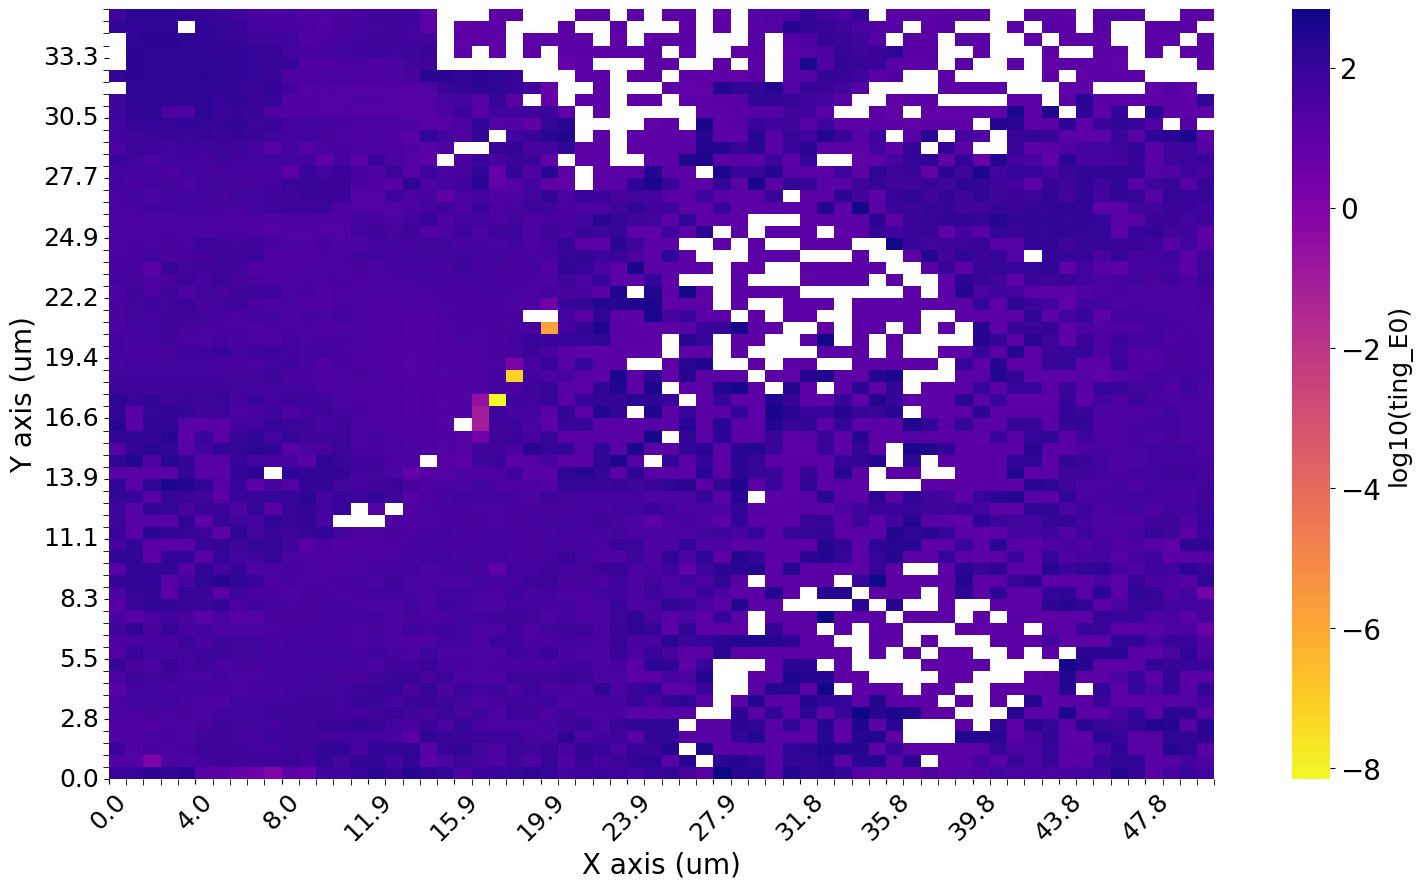

In [68]:
_ = maps.create_log_heatmap(df_merged_tdms_copy,value_key = key_hertz, annot=False,
                        save_svg=saveSVG, svg_path=os.path.join(svg_dir, f'log10_{key2}_{map_name}.svg'),
                        cmap = 'plasma', nan=True, lastColFirst=False, scale_axis=True
                        )


/Users/evillz/Github/PyFMGUI_DyNaMo_tdms/src/pyfmreader-dynamo/src/pyfmreader/ps_nex/loadpsnexMaps.py:2339: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')
/Users/evillz/Github/PyFMGUI_DyNaMo_tdms/src/pyfmreader-dynamo/src/pyfmreader/ps_nex/loadpsnexMaps.py:2339: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')
/Users/evillz/Github/PyFMGUI_DyNaMo_tdms/src/pyfmreader-dynamo/src/pyfmreader/ps_nex/loadpsnexMaps.py:2339: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i].legend(loc='upper right')


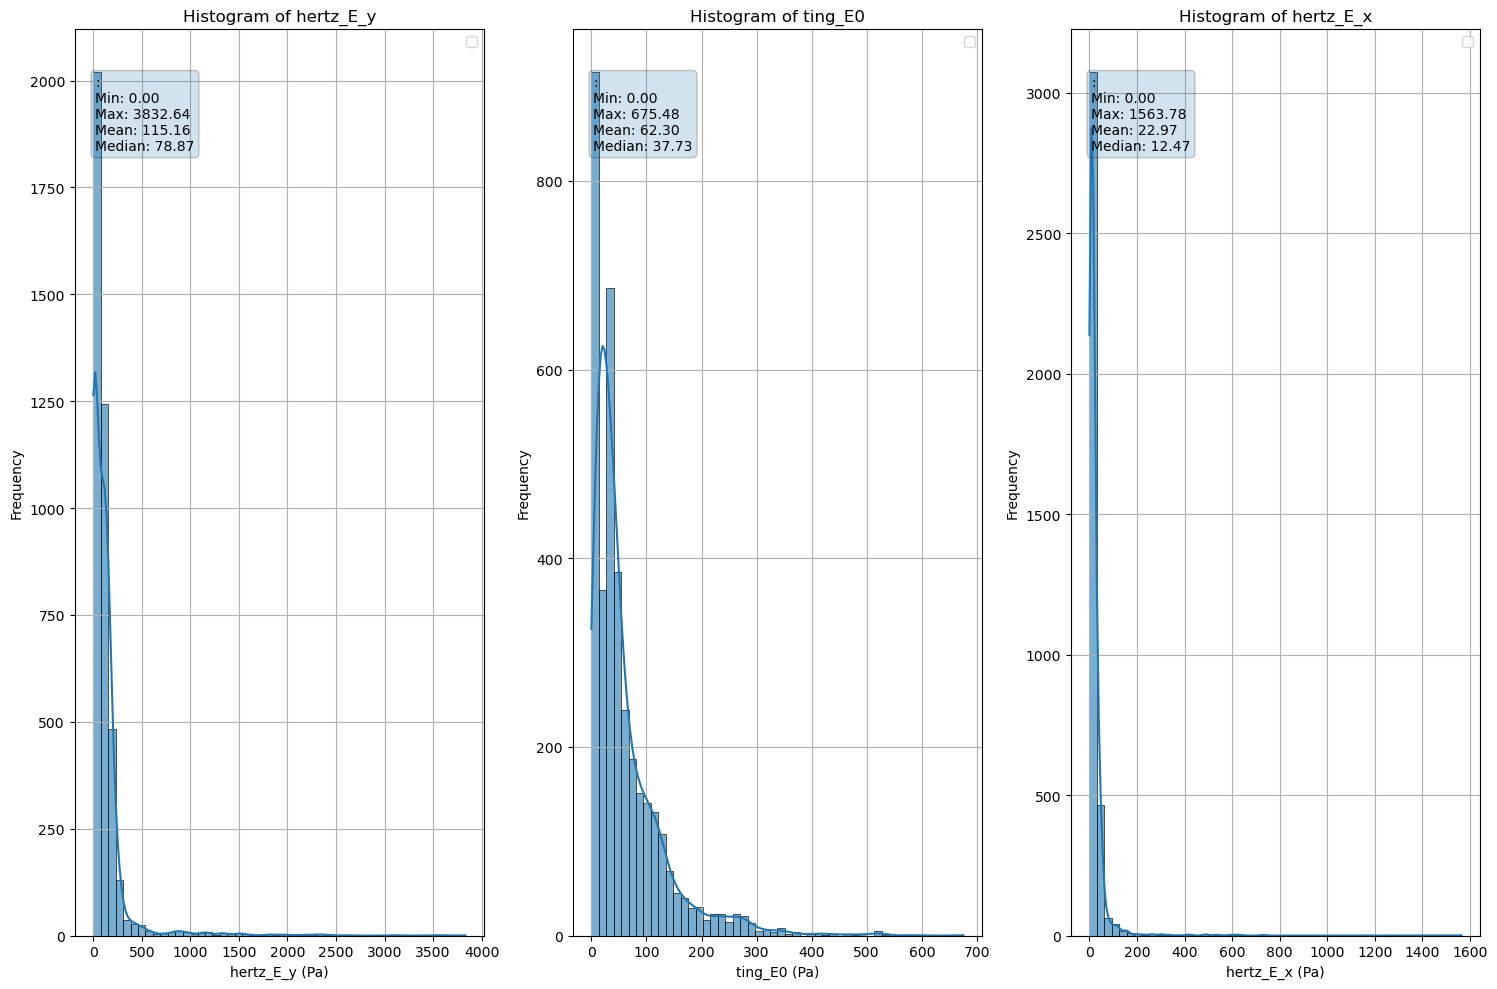

In [69]:
# generate 
# key2 = "hertz_E"
# dataframes = [(df_merged_tdms_copy, "DataFrame ting_lv"), (df_ting, "DataFrame ting_ys"), (df_ting_lv_cell2, "DataFrame ting_lv_cell2")]
dataframes = [(df_merged_tdms_copy, "")]
keys_to_plot = ['hertz_E_y', key2, 'hertz_E_x']
fig, _ = maps.create_scatter_comparison(dataframes, keys_to_plot, figsize=(15, 10))

# save histogram plot to svg_dir
if saveSVG:
    print(f"Saving histogram comparison to {svg_dir}")
    fig.savefig(os.path.join(svg_dir, f'histogram_comparison_{map_name}.svg'), transparent=True)


In [70]:
# True binning and sorted bin-wise trends for z_height vs Ting/Hertz
from scipy.ndimage import gaussian_filter1d

key_hertz = 'hertz_E'

# Select columns and clean data
df_plot = df_merged_tdms_copy[[key1, key2, key_hertz]].copy()
df_plot = df_plot.replace([np.inf, -np.inf], np.nan).dropna()
# filter out  values less than 1 for better log visualization
df_plot = df_plot[(df_plot[key2] > 10) & (df_plot[key_hertz] > 10)]   
# remove values greater than 1000 for better visualization
df_plot = df_plot[(df_plot[key2] < 500) & (df_plot[key_hertz] < 500)]



# Build explicit bins on the X variable (same idea as loadTether binning workflow)
n_bins = 6
x_min = df_plot[key1].min()
x_max = df_plot[key1].max()
bin_edges = np.linspace(x_min, x_max, n_bins + 1)

df_plot["z_bin"] = pd.cut(
    df_plot[key1],
    bins=bin_edges,
    include_lowest=True,
    ordered=True,
    duplicates="drop",
)

# Aggregate per bin (mean + SEM), then sort by bin center
grouped = (
    df_plot.groupby("z_bin", observed=True)
    .agg(
        z_mean=(key1, "mean"),
        ting_mean=(key2, "mean"),
        ting_std=(key2, "std"),
        ting_n=(key2, "count"),
        hertz_mean=(key_hertz, "mean"),
        hertz_std=(key_hertz, "std"),
        hertz_n=(key_hertz, "count"),
    )
    .reset_index()
 )

grouped["z_center"] = grouped["z_bin"].apply(lambda interval: interval.mid)
grouped["ting_sem"] = grouped["ting_std"] / np.sqrt(grouped["ting_n"].clip(lower=1))
grouped["hertz_sem"] = grouped["hertz_std"] / np.sqrt(grouped["hertz_n"].clip(lower=1))
grouped = grouped.sort_values("z_center").reset_index(drop=True)

# Optional smoothing on the bin means only (not raw points)
smooth_sigma = 2
grouped["ting_mean_smooth"] = gaussian_filter1d(grouped["ting_mean"].to_numpy(), sigma=smooth_sigma, mode="nearest")
grouped["hertz_mean_smooth"] = gaussian_filter1d(grouped["hertz_mean"].to_numpy(), sigma=smooth_sigma, mode="nearest")

# Plot raw points (light) + binned means (ordered)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=key1,
    y=key2,
    data=df_plot,
    color="tab:blue",
    alpha=0.15,
    s=20,
    label="Ting E0 raw",
)
sns.scatterplot(
    x=key1,
    y=key_hertz,
    data=df_plot,
    color="tab:orange",
    alpha=0.15,
    s=20,
    label="Hertz E raw",
)

plt.errorbar(
    grouped["z_center"],
    grouped["ting_mean_smooth"],
    yerr=grouped["ting_sem"],
    fmt="-o",
    color="tab:blue",
    linewidth=2,
    markersize=5,
    capsize=3,
    label="Ting E0 binned",
)

plt.errorbar(
    grouped["z_center"],
    grouped["hertz_mean_smooth"],
    yerr=grouped["hertz_sem"],
    fmt="-o",
    color="tab:orange",
    linewidth=2,
    markersize=5,
    capsize=3,
    label="Hertz E binned",
)

plt.title("Correlation of z_height_um_zero with Ting E0 and Hertz E (True Binned)")
plt.xlabel("z_height_um_zero")
plt.ylabel("Young's Modulus (E)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Binned points: {len(grouped)} bins used (from n_bins={n_bins})")

KeyError: "['hertz_E'] not in index"

In [ ]:
# plot ting_E0 vs hertz_E with binned means colored by z_height bins
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=key_hertz,
    y=key2,
    data=df_plot,
    color="blue",
    # alpha=0.15,
    s=20,
    label="Raw points",
)   